# Lecture 5 — Forces, energy, and stability in pedal locomotion


In [17]:
# Housekeeping code...
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle, Polygon
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from IPython.display import HTML, Video, display

if Path('../media').exists():
    MEDIA = Path('../media')
    DATA = Path('../data')
elif Path('media').exists():
    MEDIA = Path('media')
    DATA = Path('data')
else:
    raise FileNotFoundError('Run this notebook from the course repository.')

TAU = 2 * np.pi
BLUE, ORANGE, GOLD = '#3B6FB6', '#D97706', '#C9A227'
PINK, OLIVE = '#B64E77', '#718355'
INK, GREY, LIGHT = '#263238', '#9AA0A6', '#E7EAED'
G = 9.81

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.labelcolor': INK,
    'text.color': INK, 'xtick.color': INK, 'ytick.color': INK,
    'font.size': 12, 'lines.linewidth': 2.4,
    'animation.embed_limit': 30,
})

def movie(filename, start=None, stop=None, width=900):
    fragment = '' if start is None else f'#t={start}'
    if stop is not None:
        fragment += f',{stop}'
    # URL mode preserves a media fragment; audio is enabled for the TED excerpt.
    return Video(url=(MEDIA / filename).as_posix() + fragment,
                 embed=False, width=width,
                 html_attributes='controls preload="metadata" playsinline')

def spring(ax, foot, body, color=BLUE, width=.035, coils=7, lw=2):
    foot, body = np.asarray(foot), np.asarray(body)
    vector = body - foot
    length = np.linalg.norm(vector)
    tangent = vector / length
    normal = np.array([-tangent[1], tangent[0]])
    u = np.linspace(0, 1, 2 * coils + 4)
    offset = np.zeros_like(u)
    offset[2:-2] = width * (-1.) ** np.arange(len(u) - 4)
    xy = foot + u[:, None] * vector + offset[:, None] * normal
    return ax.plot(xy[:, 0], xy[:, 1], color=color, lw=lw)[0]

def slip_step(height, speed, angle, stiffness=14000., mass=70.,
              length=1., gravity=G):
    """One apex-to-apex step of a conservative spring-loaded inverted pendulum.

    Point mass, massless compression-only leg, fixed touchdown angle from
    vertical, flat ground, fixed no-slip stance foot, no drag or actuation.
    Stance is event-terminated at outward return to rest length.
    """
    touchdown_height = length * np.cos(angle)
    if height <= touchdown_height or speed <= 0:
        raise ValueError('No descending touchdown from this apex.')
    t_down = np.sqrt(2 * (height - touchdown_height) / gravity)
    foot_x = speed * t_down + length * np.sin(angle)
    initial = [speed * t_down, touchdown_height, speed, -gravity * t_down]

    def rhs(t, state):
        x, z, vx, vz = state
        leg = np.array([x - foot_x, z])
        ell = np.linalg.norm(leg)
        force = stiffness * max(length - ell, 0.) * leg / ell
        return [vx, vz, force[0] / mass, force[1] / mass - gravity]

    def liftoff(t, state):
        return np.hypot(state[0] - foot_x, state[1]) - length
    liftoff.direction, liftoff.terminal = 1, True

    def fall(t, state):
        return state[1] - .2 * length
    fall.direction, fall.terminal = -1, True

    solution = solve_ivp(rhs, (0, 2.), initial, events=(liftoff, fall),
                         rtol=1e-10, atol=1e-11, max_step=.002,
                         dense_output=True)
    if not len(solution.t_events[0]):
        raise ValueError('The leg did not reach liftoff before falling or timing out.')
    final = solution.y[:, -1]
    if final[3] <= 0 or final[2] <= 0:
        raise ValueError('No forward-moving apex after liftoff.')
    t_up = final[3] / gravity
    next_height = final[1] + final[3] ** 2 / (2 * gravity)

    td = np.linspace(0, t_down, 70, endpoint=False)
    ts = np.linspace(0, solution.t[-1], 180)
    tu = np.linspace(0, t_up, 70)[1:]
    descending = np.array([speed * td, height - .5 * gravity * td**2,
                           np.full_like(td, speed), -gravity * td])
    ascending = np.array([final[0] + final[2] * tu,
                          final[1] + final[3] * tu - .5 * gravity * tu**2,
                          np.full_like(tu, final[2]), final[3] - gravity * tu])
    state = np.column_stack([descending, solution.sol(ts), ascending]).T
    time = np.r_[td, t_down + ts, t_down + ts[-1] + tu]
    stance = np.r_[np.zeros(len(td), bool), np.ones(len(ts), bool),
                   np.zeros(len(tu), bool)]
    compression = np.where(stance,
        np.maximum(length - np.hypot(state[:, 0] - foot_x, state[:, 1]), 0), 0)
    direction = np.column_stack([state[:, 0] - foot_x, state[:, 1]])
    direction /= np.linalg.norm(direction, axis=1)[:, None]
    force = stiffness * compression[:, None] * direction
    energy = np.column_stack([
        .5 * mass * np.sum(state[:, 2:]**2, axis=1),
        mass * gravity * state[:, 1], .5 * stiffness * compression**2])
    return dict(next_height=next_height, next_speed=final[2],
                time=time, state=state, stance=stance, force=force,
                energy=energy, foot_x=foot_x, touchdown=t_down,
                liftoff=t_down + ts[-1], angle=angle, mass=mass,
                length=length, stiffness=stiffness)

def periodic_angle(height, speed, bracket=(.1, .8), **parameters):
    return brentq(lambda angle:
        slip_step(height, speed, angle, **parameters)['next_height'] - height,
        *bracket, xtol=1e-12)


## Ground reaction forces determine center-of-mass motion

<img src="../media/locomotion-force-and-template.png" width="1100">


Let $\mathbf r=(x,z)$ be the center-of-mass position. The total ground reaction force is

$$
\mathbf F=\sum_i\mathbf F_i,
$$

where the sum runs over the *feet* in contact.

$$
m\ddot x=F_x,\qquad m\ddot z=F_z-mg.
$$

A leg that contacts ahead of the body produces $F_x<0$; a leg behind the body produces $F_x>0$. Thus a runner can brake and accelerate within every stride while maintaining a constant average speed.


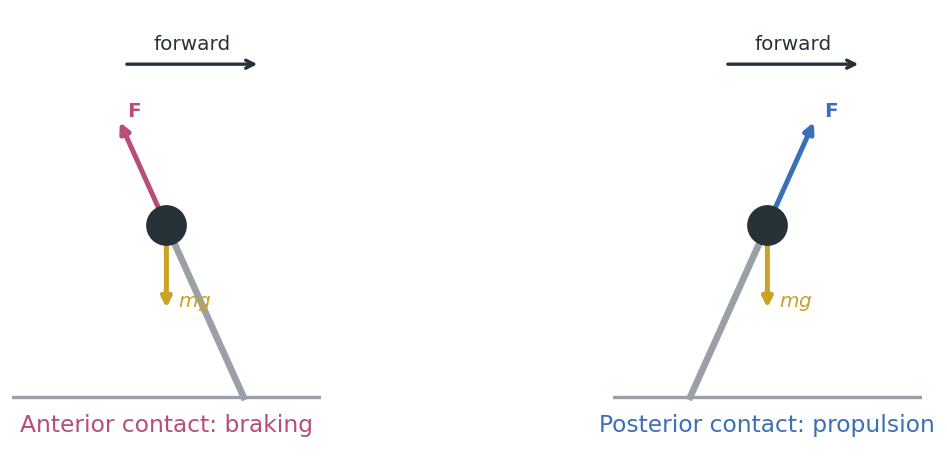

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout='constrained')
for ax, foot_x, text, color in zip(axes, [.45, -.45],
        ['Anterior contact: braking', 'Posterior contact: propulsion'], [PINK, BLUE]):
    body = np.array([0., 1.])
    foot = np.array([foot_x, 0.])
    ax.axhline(0, color=GREY, lw=2)
    ax.plot([foot_x, 0], [0, 1], color=GREY, lw=4)
    ax.scatter(*body, s=550, color=INK, zorder=4)
    force = .68 * (body - foot) / np.linalg.norm(body - foot)
    ax.annotate('', body + force, body,
                arrowprops=dict(arrowstyle='-|>', color=color, lw=3))
    ax.text(*(body + force + [.05, .02]), r'$\mathbf{F}$', color=color)
    ax.annotate('', (0, .5), body,
                arrowprops=dict(arrowstyle='-|>', color=GOLD, lw=3))
    ax.text(.07, .53, '$mg$', color=GOLD)
    ax.annotate('', (.55, 1.94), (-.25, 1.94),
                arrowprops=dict(arrowstyle='->', color=INK, lw=2))
    ax.text(.15, 2.03, 'forward', ha='center')
    ax.text(0, -.2, text, ha='center', fontsize=14, color=color)
    ax.set(xlim=(-.9, .9), ylim=(-.35, 2.25), aspect='equal')
    ax.axis('off')
plt.show()


### Impulse changes momentum

Integrating Newton's equation over one gait cycle of duration $T$ gives

$$
m[\dot x(T)-\dot x(0)]=\int_0^T F_x(t)\,dt,
$$

$$
m[\dot z(T)-\dot z(0)]=\int_0^T [F_z(t)-mg]\,dt.
$$

For a periodic gait, the velocity repeats after every cycle. Therefore

$$
\boxed{\int_0^T F_x(t)\,dt=0},\qquad
\boxed{\int_0^T F_z(t)\,dt=mgT}.
$$

The horizontal impulses cancel over a cycle; the vertical ground impulse balances the gravitational impulse.


### Contact duration sets the force scale

For a single-leg hopper, let $T_c$ be the contact time and define the contact fraction

$$
\beta=\frac{T_c}{T}.
$$

The vertical impulse condition becomes

$$
\langle F_z\rangle_{\text{contact}}T_c=mgT
\quad\Longrightarrow\quad
\boxed{\langle F_z\rangle_{\text{contact}}=\frac{mg}{\beta}.}
$$

Reducing contact time requires a larger mean force during contact. In a many-legged animal, simultaneous contacts can share the required impulse.


## Walking as an inverted-pendulum

Consider a rigid, massless leg of length $\ell_0$. During a single stride, the foot remains fixed and the center of mass follows a circular arc:

$$
x=\ell_0\sin\gamma,\qquad z=\ell_0\cos\gamma.
$$

$\gamma$ is the leg angle from vertical.  The center of mass reaches its maximum height at $\gamma=0$ (midstance).

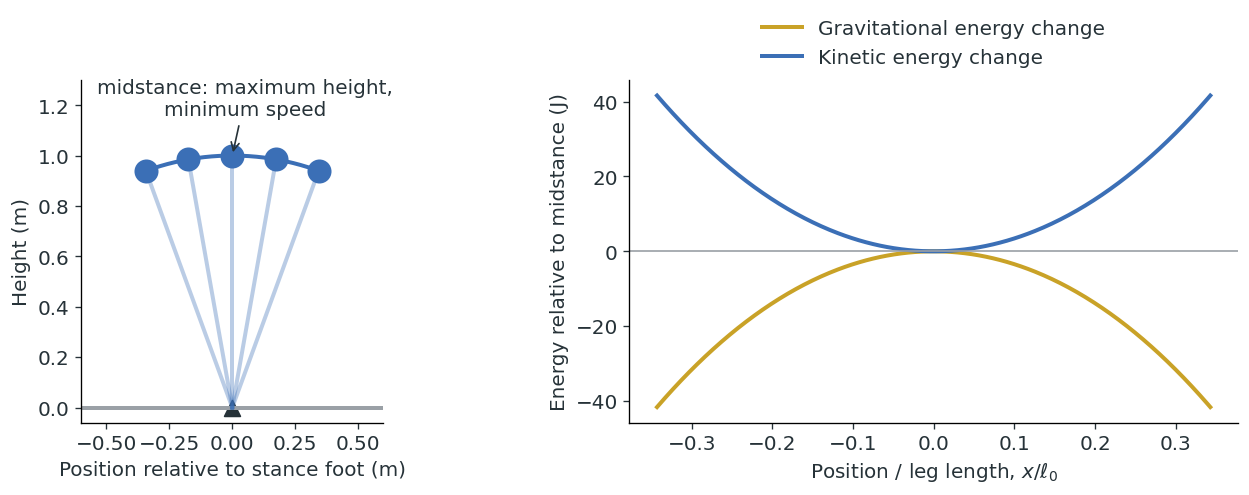

In [19]:
ell0, mass, midstance_speed = 1., 70., 1.4
gamma = np.linspace(-.35, .35, 401)
x_walk, z_walk = ell0 * np.sin(gamma), ell0 * np.cos(gamma)
potential_walk = mass * G * z_walk
total_walk = mass * G * ell0 + .5 * mass * midstance_speed**2
kinetic_walk = total_walk - potential_walk
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
ax = axes[0]
ax.axhline(0, color=GREY)
ax.plot(x_walk, z_walk, color=BLUE)
for i in [0, 100, 200, 300, 400]:
    ax.plot([0, x_walk[i]], [0, z_walk[i]], color=BLUE, alpha=.35)
    ax.scatter(x_walk[i], z_walk[i], s=180, color=BLUE, zorder=3)
ax.scatter(0, 0, marker='^', s=90, color=INK)
ax.annotate('midstance: maximum height,\nminimum speed', (0, 1), (.05, 1.16),
            arrowprops=dict(arrowstyle='->', color=INK), ha='center')
ax.set(xlabel='Position relative to stance foot (m)', ylabel='Height (m)',
       xlim=(-.6, .6), ylim=(-.06, 1.3), aspect='equal')
ax = axes[1]
# Subtract each curve's own midstance value to expose the exchange.
ax.plot(x_walk / ell0, potential_walk - potential_walk[200], color=GOLD,
        label='Gravitational energy change')
ax.plot(x_walk / ell0, kinetic_walk - kinetic_walk[200], color=BLUE,
        label='Kinetic energy change')
ax.axhline(0, color=GREY, lw=1)
ax.set(xlabel=r'Position / leg length, $x/\ell_0$',
       ylabel='Energy relative to midstance (J)')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(.5, 1.23))
plt.show()


### Walking exchanges kinetic and gravitational energy

For this circular body path, $\mathbf F\cdot\dot{\mathbf r}=0$: the leg force does no work.

$$
\frac{d}{dt}(E_{\rm kin}+E_g)
=\mathbf F\cdot\dot{\mathbf r}=0,
$$

with

$$
E_{\rm kin}=\frac12m|\dot{\mathbf r}|^2,\qquad E_g=mgz.
$$

As the body rises toward midstance, kinetic energy is converted into gravitational potential energy. The conversion reverses during the second half of stance.

*(Note, we are ignoring the leg swing phase of the gait and energy lost when support transfers between legs etc.)*


### Contact constraints

At midstance, the center of mass has downward centripetal acceleration $v^2/\ell_0$. The vertical force balance is therefore

$$
F_z-mg=-\frac{mv^2}{\ell_0},
\qquad \frac{F_z}{mg}=1-\underbrace{\frac{v^2}{g\ell_0}}_{\displaystyle \mathrm{Fr}}.
$$

A passive ground contact can push but cannot pull, so $F_z\geq0$. Hence

$$
F_z\geq0\quad\Longrightarrow\quad \mathrm{Fr}\leq1.
$$

$\mathrm{Fr}=v^2/(g\ell_0)$ is the Froude number.

$\mathrm{Fr}=1$ sets a limit on walking, where the foot loses contact with the ground. 

Humans typically change gait near $\mathrm{Fr}\simeq0.5$ when $v$ is taken as average forward speed.


### Dynamic similarity predicts a speed scale

Animals of different sizes tend to walk at similar Froude numbers:

$$
\mathrm{Fr}=\frac{v^2}{g\ell_0}=\text{constant}
\quad\Longrightarrow\quad
v\propto\sqrt{g\ell_0}.
$$

Animal speed scales as the square root of size (leg length).

Even within a single species, reduced-gravity treadmill experiments yield lower preferred walk-run transition speeds while the transition Froude number remained approximately constant. 


## Running as a spring–mass system

We model running as a spring–mass system, in which the leg compresses and stores elastic energy during ground contact, and the body is airborne for part of each gait cycle.

The spring-loaded inverted pendulum (SLIP) model replaces the rigid stance leg with a massless spring of rest length $\ell_0$ and stiffness $k$. Let $\mathbf r_f=(x_f,0)$ be the fixed stance foot and

$$
\ell=|\mathbf r-\mathbf r_f|.
$$

During compression, $\ell\leq\ell_0$, the equation of motion is

$$
m\ddot{\mathbf r}
=k(\ell_0-\ell)\frac{\mathbf r-\mathbf r_f}{\ell}-mg\hat{\mathbf z},
\qquad \ell\leq\ell_0.
$$

When the animal is in the air, the ground force vanishes, so $\ddot x=0$ and $\ddot z=-g$.

A step is completed by prescribing the touchdown angle $\gamma_{\rm td}$ and lifting off when the spring re-extends to $\ell_0$.

Model example: $m=70$ kg, $\ell_0=1$ m, $k=14$ kN/m.


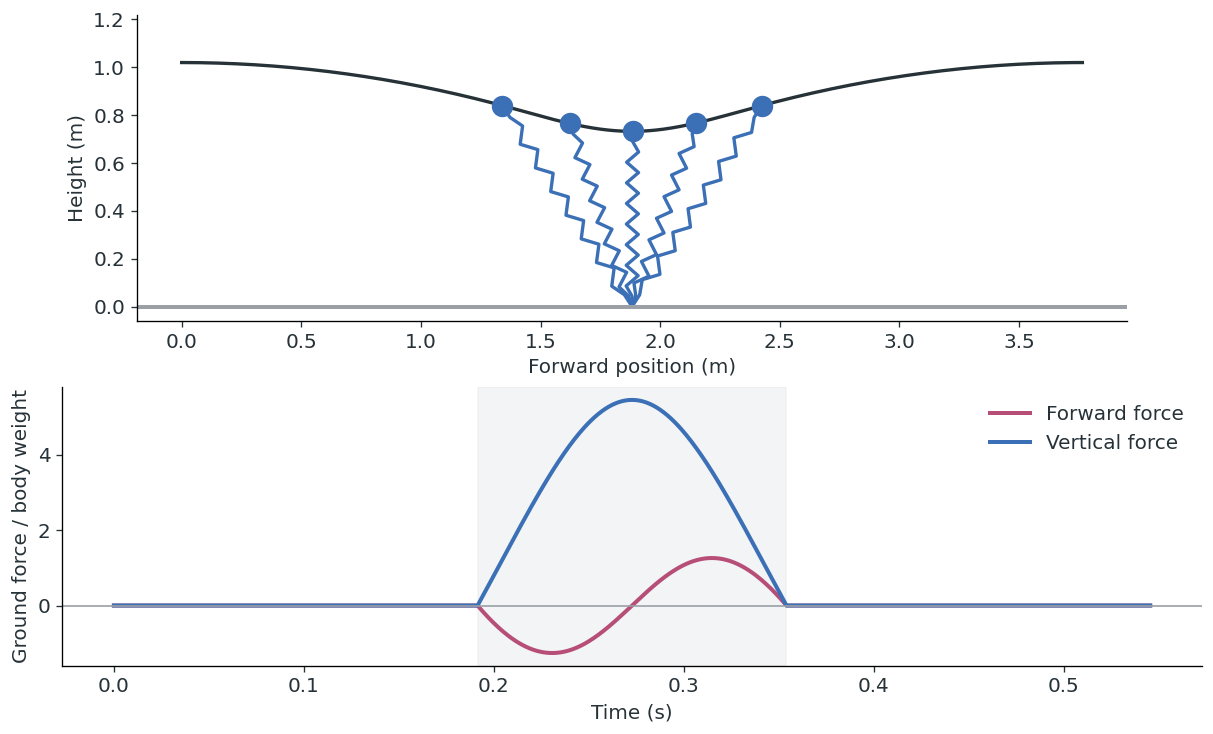

In [20]:
# Model parameters, chosen for a clear repeatable running step; not an animal fit.
MASS, REST_LENGTH, STIFFNESS = 70., 1., 14000.
APEX_HEIGHT, RUN_SPEED = 1.02, 7.
TOUCHDOWN_ANGLE = periodic_angle(APEX_HEIGHT, RUN_SPEED, bracket=(.50, .65))
run = slip_step(APEX_HEIGHT, RUN_SPEED, TOUCHDOWN_ANGLE)
assert abs(run['next_height'] - APEX_HEIGHT) < 1e-8
assert abs(run['next_speed'] - RUN_SPEED) < 1e-6

fig, axes = plt.subplots(2, 1, figsize=(10, 6), layout='constrained',
                         gridspec_kw={'height_ratios': [1.1, 1]})
ax = axes[0]
ax.plot(run['state'][:, 0], run['state'][:, 1], color=INK, lw=2)
stance_indices = np.flatnonzero(run['stance'])
for i in stance_indices[[0, 45, 90, 135, -1]]:
    spring(ax, [run['foot_x'], 0], run['state'][i, :2], color=BLUE, width=.025)
    ax.scatter(*run['state'][i, :2], s=140, color=BLUE, zorder=4)
ax.axhline(0, color=GREY)
ax.set(xlabel='Forward position (m)', ylabel='Height (m)',
       ylim=(-.06, 1.22), aspect='equal')
ax = axes[1]
for j, label, color in [(0, 'Forward force', PINK), (1, 'Vertical force', BLUE)]:
    ax.plot(run['time'], run['force'][:, j] / (MASS * G), color=color, label=label)
ax.axhline(0, color=GREY, lw=1)
ax.axvspan(run['touchdown'], run['liftoff'], color=LIGHT, alpha=.5)
ax.set(xlabel='Time (s)', ylabel='Ground force / body weight')
ax.legend(frameon=False, loc='upper right')
plt.show()


In [21]:
# One repeatable step, replayed slowly so stance and flight remain visible.
fig, ax = plt.subplots(figsize=(9, 3.5), layout='constrained')
ax.plot(run['state'][:, 0], run['state'][:, 1], color=LIGHT, lw=3)
ax.axhline(0, color=GREY)
body_dot, = ax.plot([], [], 'o', ms=15, color=BLUE)
leg_line, = ax.plot([], [], color=BLUE, lw=2)
clock_text = ax.text(.02, .92, '', transform=ax.transAxes)
ax.set(xlim=(-.12, run['state'][-1, 0] + .12), ylim=(-.05, 1.2),
       xlabel='Forward position (m)', ylabel='Height (m)', aspect='equal')
frame_times = np.linspace(run['time'][0], run['time'][-1], 90)
frame_indices = np.array([np.argmin(abs(run['time'] - t)) for t in frame_times])

def animate_step(frame):
    i = frame_indices[frame]
    body = run['state'][i, :2]
    body_dot.set_data([body[0]], [body[1]])
    if run['stance'][i]:
        foot = np.array([run['foot_x'], 0.])
        vec = body - foot
        normal = np.array([-vec[1], vec[0]]) / np.linalg.norm(vec)
        u = np.linspace(0, 1, 18)
        offsets = np.zeros_like(u)
        offsets[2:-2] = .025 * (-1.) ** np.arange(14)
        xy = foot + u[:, None] * vec + offsets[:, None] * normal
        leg_line.set_data(xy[:, 0], xy[:, 1])
    else:
        leg_line.set_data([], [])
    phase = 'stance' if run['stance'][i] else 'flight'
    clock_text.set_text(f"time = {run['time'][i]:.3f} s  |  {phase}")
    return body_dot, leg_line, clock_text

animation = FuncAnimation(fig, animate_step, frames=len(frame_indices),
                           interval=45, blit=False)
display(HTML(animation.to_jshtml(default_mode='loop')))
plt.close(fig)


### Compression stores energy; recoil returns it

$$
E_{\rm spring}=\frac12 k(\ell_0-\ell)^2,
\qquad
E=E_{\rm kin}+E_g+E_{\rm spring}.
$$

At touchdown, the spring is uncompressed. During the first half of stance, the body slows and descends while the leg compresses; kinetic and gravitational energy are stored elastically. Recoil reverses that exchange before liftoff.


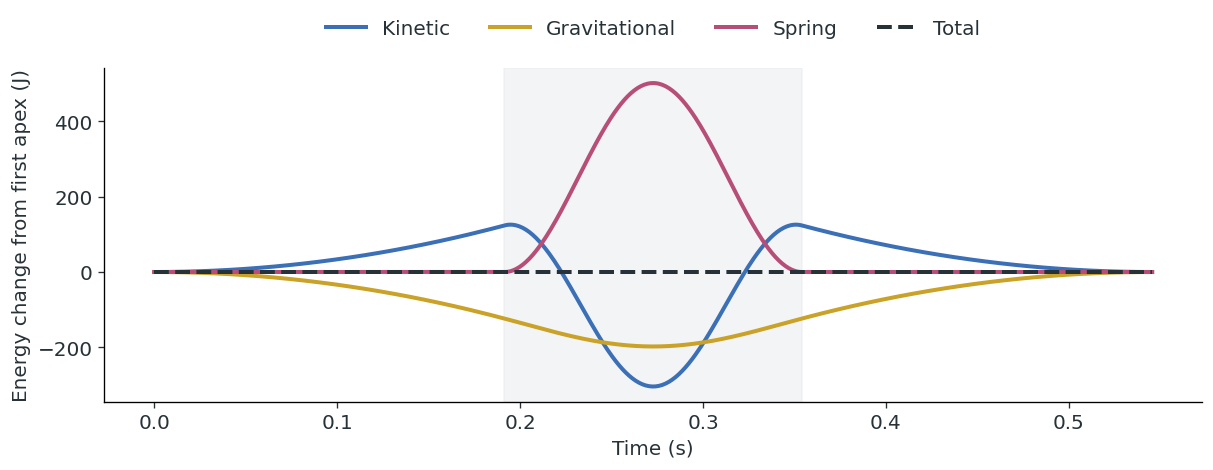

In [22]:
fig, ax = plt.subplots(figsize=(10, 3.8), layout='constrained')
energy_change = run['energy'] - run['energy'][0]
for j, label, color in [(0, 'Kinetic', BLUE), (1, 'Gravitational', GOLD),
                         (2, 'Spring', PINK)]:
    ax.plot(run['time'], energy_change[:, j], label=label, color=color)
ax.plot(run['time'], energy_change.sum(axis=1), '--', color=INK, label='Total')
ax.axvspan(run['touchdown'], run['liftoff'], color=LIGHT, alpha=.5)
ax.set(xlabel='Time (s)', ylabel='Energy change from first apex (J)')
ax.legend(frameon=False, ncols=4, loc='upper center', bbox_to_anchor=(.5, 1.2))
assert np.ptp(run['energy'].sum(axis=1)) / run['energy'][0].sum() < 1e-7
plt.show()


## Gait switching due to energetics

### Leg swing sets a time scale

The free leg swings forward about the hip. Thinking about it as a simple pendulum of length $\ell_{\rm sw}$:

$$
\omega_{\rm sw}=\sqrt{\frac{g}{\ell_{\rm sw}}},
\qquad
t_{\rm swing}\simeq\pi\sqrt{\frac{\ell_{\rm sw}}{g}}.
$$

Faster walking eventually requires actively driving the leg faster than its natural timescale.


### Its hard to walk with long steps

At the end of a step, the body must accelerate toward the foot to remain on a circular arc. 

In the radial direction:

$$
mg\cos\theta-F=\frac{mv^2}{\ell_0}.
$$

As speed increases, the required inward acceleration increases and $F$ has to decrease. Contact with the ground is lost when $F=0$, so

$$
v^2\leq g\ell_0\cos\theta.
$$

For this inequality to hold as $v$ increases, $\theta$ must decrease, shortening the step:

$$
l_{\rm step}=2\ell_0\sin\theta.
$$


### Shorter steps require faster leg swing

For this step length, the walking speed is:

$$
\bar v=\frac{l_{\rm step}}{t_{\rm step}}.
$$

As $v$ increases, $l_{\rm step}$ decreases, so $t_{\rm step}$ must become even shorter. Walking becomes costly when it approaches the natural swing time:

$$
v^*\sim\frac{l_{\rm step}}{t_{\rm swing}}
=\frac{l_{\rm step}}{\pi}\sqrt{\frac{g}{\ell_{\rm sw}}}.
$$

Because $l_{\rm step}$ and $\ell_{\rm sw}$ both scale with leg length,

$$
v^*\sim\sqrt{g\ell_0}.
$$

For $g\simeq9.8\,\mathrm{m/s^2}$ and $\ell_0\simeq1\,\mathrm{m}$,

$$
v^*\sim\sqrt{(9.8\,\mathrm{m/s^2})(1\,\mathrm{m})}\simeq3\,\mathrm{m/s}.
$$


## Lessons in stability from the lowly cockroach


In [23]:
# The archived teaching compilation: cockroach-inspired robots and passive mechanics.
# Adjust these endpoints to choose a different excerpt before class.
movie('bob-full-locomotion-ted-excerpt-vscode.mp4', start=180, stop=345)


In [24]:
movie('cockroach-jetpack.mp4', width=480)


### Recovery begins within a single stride

The lateral velocity decreases after $13\pm5\,\mathrm{ms}$ and recovers in $27\pm12\,\mathrm{ms}$!


### A sideways perturbation: the cannon

Cockroach legs are sprawled out sideways. A lateral displacement compresses the legs on one side and extends those on the other. For a small perturbation $\eta$,

$$
m\ddot\eta=-k_\perp\eta-c_\perp\dot\eta.
$$

The stiffness returns the body toward its path; damping removes lateral motion. Their balance is measured by

$$
\zeta=\frac{c_\perp}{2\sqrt{mk_\perp}}.
$$

- $0<\zeta<1$: underdamped; oscillatory return.
- $\zeta=1$: critical damping; fastest return without overshoot.
- $\zeta>1$: overdamped; nonoscillatory but slower return.


Jindrich and Full fit the lateral recovery trajectory after the cannon perturbation:

$$
t_{\rm elastic}=\frac{1}{\sqrt{\kappa}}\simeq16\,\mathrm{ms},
\qquad
\zeta=\frac{b_{\rm lat}}{2\sqrt{\kappa}}\simeq0.2.
$$

- The fitted lateral stiffness, about $15\,\mathrm{N/m}$, agrees with the $16\,\mathrm{N/m}$ predicted from force measurements on unperturbed running. 

- The full viscoelastic model accounts for $74\pm17\%$ of the measured acceleration.


## Passive does not mean inactive

- This kind of stability is passive in that the animal does not have to actively monitor the perturbations and act on them. Perturbations decrease on their own.

- But, the animal can tune the mechanical properties by tensing muscles etc.


## Sources

- Michael H. Dickinson *et al.*, [“How Animals Move: An Integrative View”](https://doi.org/10.1126/science.288.5463.100), *Science* 288, 100–106 (2000).
- Reinhard Blickhan, [“The spring-mass model for running and hopping”](https://doi.org/10.1016/0021-9290(89)90224-8), *Journal of Biomechanics* 22, 1217–1227 (1989).
- Rodger Kram, Antoinette Domingo, and Daniel P. Ferris, [“Effect of reduced gravity on the preferred walk–run transition speed”](https://doi.org/10.1242/jeb.200.4.821), *Journal of Experimental Biology* 200, 821–826 (1997).
- James Richard Usherwood, [“Why not walk faster?”](https://doi.org/10.1098/rsbl.2005.0312), *Biology Letters* 1, 338–341 (2005).
- Robert J. Full *et al.*, [“Quantifying Dynamic Stability and Maneuverability in Legged Locomotion”](https://doi.org/10.1093/icb/42.1.149), *Integrative and Comparative Biology* 42, 149–157 (2002).
- Devin L. Jindrich and Robert J. Full, [“Dynamic stabilization of rapid hexapedal locomotion”](https://doi.org/10.1242/jeb.205.18.2803), *Journal of Experimental Biology* 205, 2803–2823 (2002).
- Andy Ruina, John E. A. Bertram, and Manoj Srinivasan, [“A collisional model of the energetic cost of support work qualitatively explains leg sequencing in walking and the walk-to-run transition”](https://doi.org/10.1016/j.jtbi.2005.04.004), *Journal of Theoretical Biology* 237, 170–192 (2005).
- Manoj Srinivasan and Andy Ruina, [“Computer optimization of a minimal biped model discovers walking and running”](https://doi.org/10.1038/nature04113), *Nature* 439, 72–75 (2006).
- Robert Full, [“Robots inspired by cockroach ingenuity”](https://www.ted.com/talks/robert_full_robots_inspired_by_cockroach_ingenuity), TED2002.
